# Modulacije

## 1. Šta je zadatak telekomunikacija

Cilj telekomunikacionog sistema je **pouzdan prenos informacije**. Inženjerski deo posla je borba sa štetnim efektima
koji su prirodno prisutni u svakom kanalu: šum, eho i sl.

## 2. SNR — odnos signal/šum

Osnovna metrika kvaliteta kanala je **odnos signal/šum** (SNR): odnos snage korisnog signala
$P_s$ i snage šuma $P_n$. Skoro uvek se izražava u decibelima:

$$ \mathrm{SNR_{dB}} = 10 \cdot \log_{10}\frac{P_s}{P_n} $$

Decibeli se koriste jer sistemi rade u ogromnom rasponu odnosa (lepše je reći „−10 do 40 dB"
nego „0.1 do 10000"). **0 dB** znači da su signal i šum podjednako jaki; pozitivno → signal vodi,
negativno → šum vodi.

Šum se najčešće modeluje **Gausovom (normalnom) raspodelom** sa srednjom vrednošću 0; njegova
snaga je varijansa $\sigma^2$, pa je $\sigma=\sqrt{P_n}$. Funkcija `np.random.randn` daje Gausov
šum sa $\sigma=1$, pa se množenjem sa $\sqrt{P_n}$ podešava željena snaga.

Sledi sinusoida degradirana Gausovim šumom za nekoliko vrednosti SNR-a:

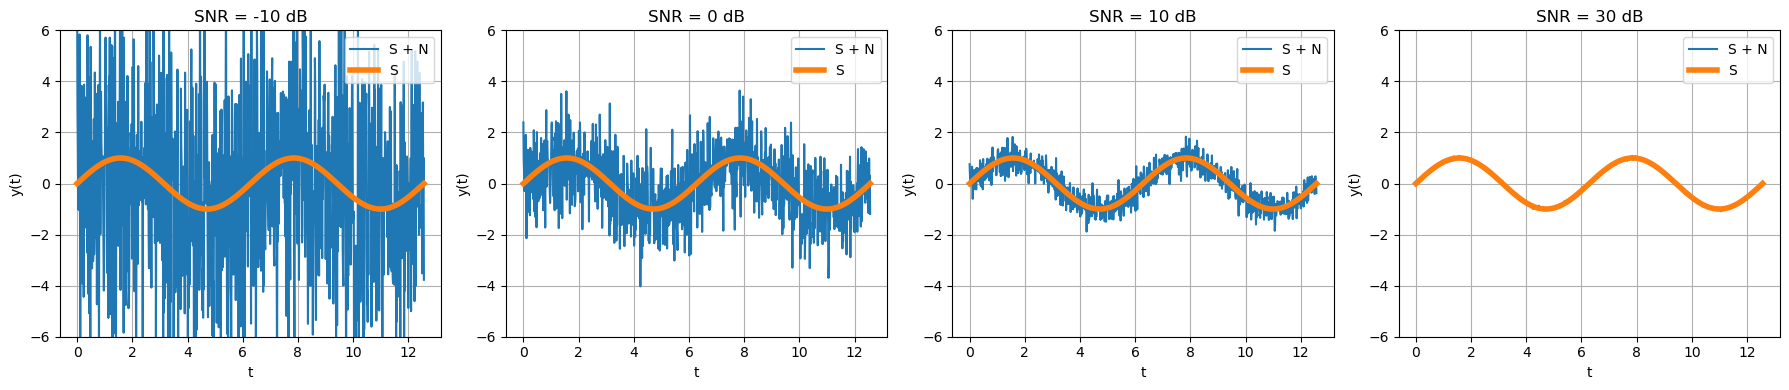

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.signal import welch

t = np.linspace(0, 4 * np.pi, 1000)
snrs = [-10, 0, 10, 30]
signal_demo = np.sin(t)
noise = np.random.randn(1000)

plt.figure(figsize=(18, 4))
for i, snr in enumerate(snrs):
    plt.subplot(1, len(snrs), i + 1)
    plt.plot(t, signal_demo + noise * np.sqrt(10**(-0.1 * snr)), label="S + N")
    plt.plot(t, signal_demo, linewidth=4, label="S")
    plt.title(f"SNR = {snr} dB")
    plt.ylim([-6, 6]); plt.xlabel("t"); plt.ylabel("y(t)")
    plt.legend(); plt.grid()
plt.tight_layout(); plt.show()

Na nižim SNR-ovima pouzdanost prenosa pati — greške su neizbežne. Ako usporimo prenos i
usrednjimo signal kroz duže vreme, srednja vrednost šuma teži nuli, pa mu uticaj opada.
Zato su brzina prenosa i otpornost na šum u stalnoj razmeni.

**Interaktivno** — pomeri SNR i gledaj kada signal proviri ispod šuma:

In [2]:
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown

t_snr = np.linspace(0, 4*np.pi, 1000)
sig_snr = np.sin(t_snr)
sum_snr = np.random.randn(1000)

def prikazi_snr(SNR=10):
    plt.figure(figsize=(12, 3))
    plt.plot(t_snr, sig_snr + sum_snr*np.sqrt(10**(-0.1*SNR)), label="signal + šum")
    plt.plot(t_snr, sig_snr, linewidth=3, label="signal")
    plt.ylim([-6, 6]); plt.title(f"SNR = {SNR} dB"); plt.legend(); plt.grid(); plt.show()

interact(prikazi_snr, SNR=IntSlider(min=-15, max=40, step=1, value=10));

interactive(children=(IntSlider(value=10, description='SNR', max=40, min=-15), Output()), _dom_classes=('widge…

## 3. Zašto uopšte modulacija

Prirodan signal (npr. zvuk) leži na niskim učestanostima, oko 0 Hz. Takav ga ne možemo poslati:
efikasna antena bila bi ogromna, a kad bi svi slali oko 0 Hz, svi bi se preklapali.

**Modulacija** pomeri signal u deo spektra gde ga originalno nema (visoke učestanosti, kratke antene),
i to za različite korisnike na različita mesta — pa ih je moguće razdvojiti. Prijemnik bira deo spektra
koji želi, podesi se na njega i izvrši **demodulaciju** (vraćanje u originalni opseg).

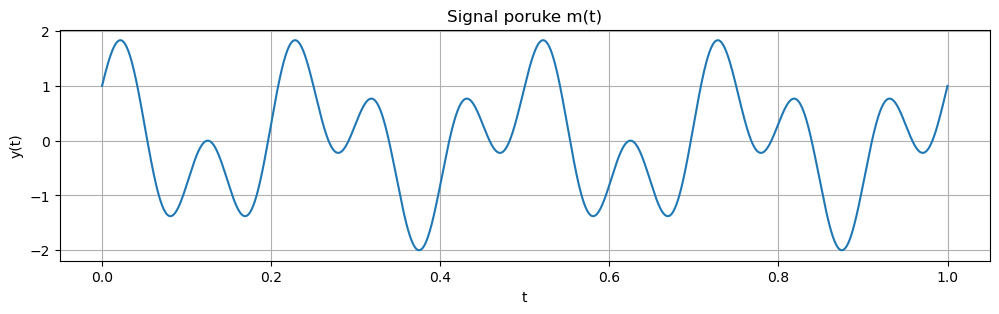

In [3]:
fs = 10**5          # frekvencija odabiranja (100 kHz)
tmax = 1            # trajanje [s]
t = np.linspace(0, tmax, fs * tmax)

f1, f2 = 4, 10
createSignal = lambda t: np.cos(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)
signal = createSignal(t)

plt.figure(figsize=(12, 3))
plt.plot(t, signal); plt.grid()
plt.xlabel("t"); plt.ylabel("y(t)"); plt.title("Signal poruke m(t)")
plt.show()

### 3.2 Spektar — podsetnik na Furijeovu transformaciju

Funkcija `showSpect` računa spektar preko FFT-a. Dve korekcije: deljenje sa $N$ vraća prave
amplitude (sirovi FFT je $N$ puta veći), a množenje sa 2 nadoknađuje to što se realna sinusoida
deli na dva pika ($+f$ i $-f$), pa prikazani pik pokazuje pravu amplitudu. Amplituda se prikazuje
u decibelima: $20\log_{10}|H|$, gde amplituda 1 → 0 dB, a $\tfrac12$ → −6 dB.

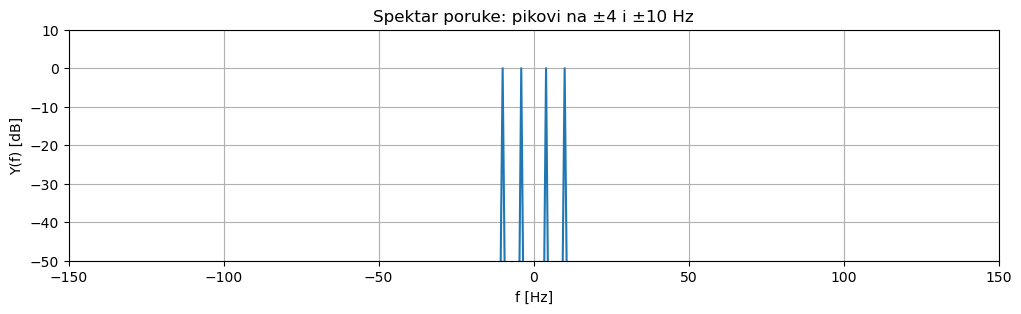

In [4]:
def showSpect(signal, lim=(-150, 150)):
    H = np.fft.fft(signal) / len(signal) * 2
    w = np.fft.fftfreq(len(signal), d=1/fs)
    plt.plot(w, 20 * np.log10(np.abs(H) + 1e-12))
    plt.xlim(lim); plt.ylim([-50, 10])
    plt.xlabel("f [Hz]"); plt.ylabel("Y(f) [dB]")

plt.figure(figsize=(12, 3))
showSpect(signal); plt.grid()
plt.title("Spektar poruke: pikovi na ±4 i ±10 Hz")
plt.show()

## 4. AM — amplitudska modulacija (DSB-SC)

Najjednostavnija modulacija: **pomnožimo poruku nosiocem** (sinusoidom na $f_c$). To je sve.

$$ s(t) = m(t)\cdot\cos(2\pi f_c t) $$

Po **teoremi modulacije**, množenje sa $\cos$ kopira spektar poruke oko $\pm f_c$. Nosilac je
mnogo viši od frekvencija poruke (ovde 125 Hz prema 4–10 Hz). Ovaj oblik se zove DSB-SC
(dvostruki bočni opseg, potisnut nosilac).

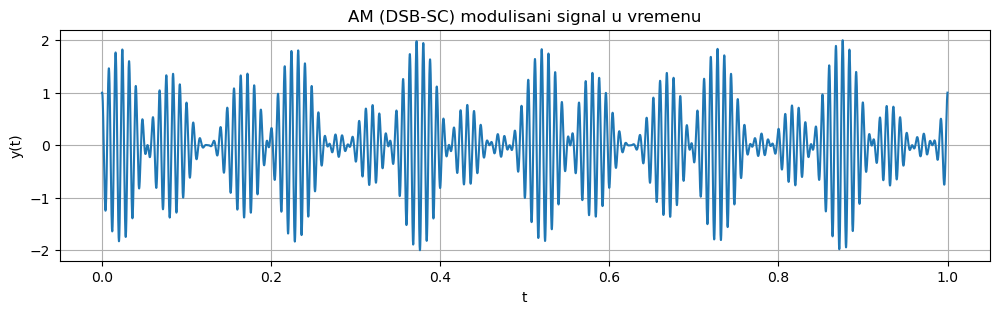

In [5]:
fc = 125
carrier = np.cos(2 * np.pi * fc * t)
modulatedSignal = signal * carrier

plt.figure(figsize=(12, 3))
plt.plot(t, modulatedSignal); plt.grid()
plt.xlabel("t"); plt.ylabel("y(t)"); plt.title("AM (DSB-SC) modulisani signal u vremenu")
plt.show()

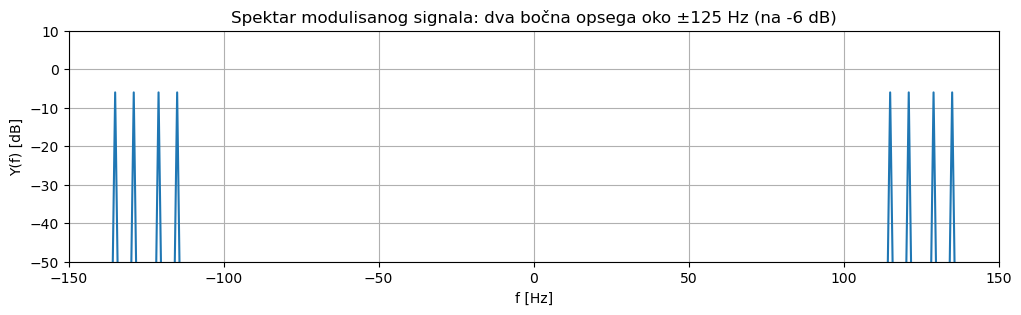

In [6]:
plt.figure(figsize=(12, 3))
showSpect(modulatedSignal); plt.grid()
plt.title("Spektar modulisanog signala: dva bočna opsega oko ±125 Hz (na -6 dB)")
plt.show()

Pikovi su se preselili oko $\pm f_c$ i duplirali u bočne opsege na **−6 dB** (snaga se razlila
na dve identične kopije).

### 4.1 Demodulacija množenjem nosiocem

Signal vraćamo množenjem istim nosiocem još jednom. Pomoću $\cos^2\theta=\tfrac12+\tfrac12\cos 2\theta$:

$$ s(t)\cos(2\pi f_c t) = \underbrace{\tfrac12 m(t)}_{\text{oko 0 Hz}} + \underbrace{\tfrac12 m(t)\cos(2\pi\cdot 2f_c t)}_{\text{oko } 2f_c} $$

Kopija poruke se vraća na 0 Hz, a višak je na $2f_c$. **Niskopropusni filtar** (zasebna tema)
zadržao bi samo deo oko 0 Hz. Na spektru se to lepo vidi:

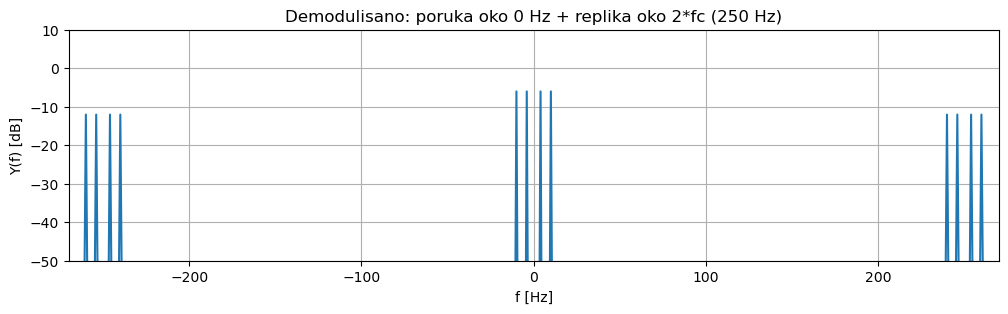

In [7]:
demodulated = carrier * modulatedSignal

plt.figure(figsize=(12, 3))
showSpect(demodulated, lim=(-270, 270)); plt.grid()
plt.title("Demodulisano: poruka oko 0 Hz + replika oko 2*fc (250 Hz)")
plt.show()

### Product detector

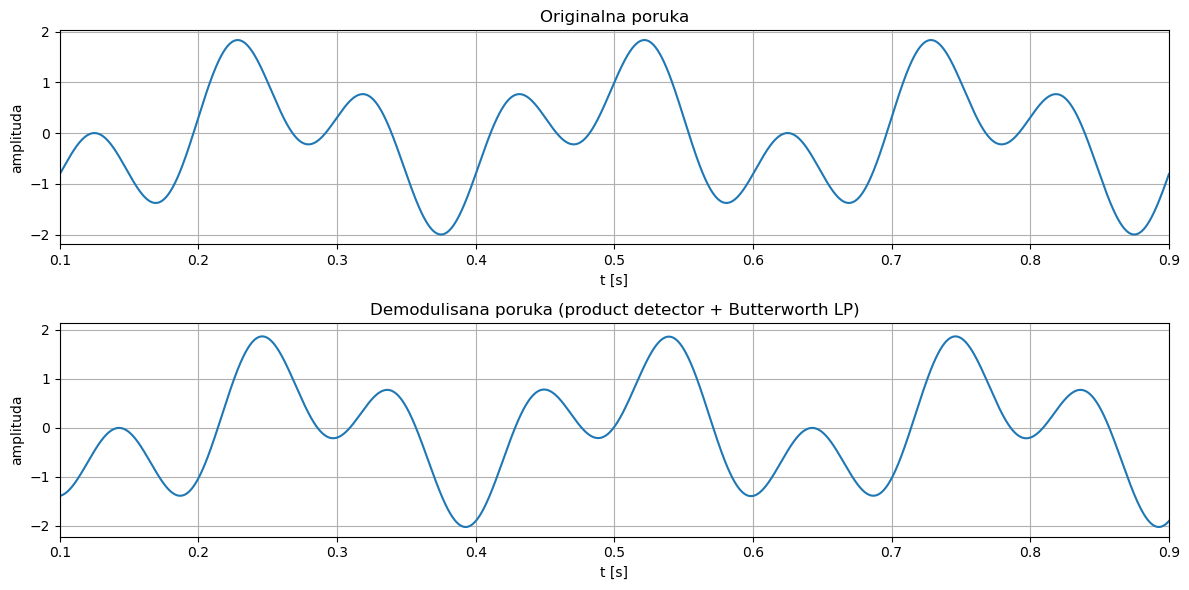

In [8]:
from scipy.signal import butter, lfilter

# --- niskopropusni Butterworth filtar za izdvajanje poruke ---
def butter_lowpass(granicna_frekvencija, fs, red=5):
    nyquist = 0.5 * fs
    b, a = butter(red, granicna_frekvencija / nyquist, btype="low", analog=False)
    return b, a

def butter_lowpass_filter(podaci, granicna_frekvencija, fs, red=5):
    b, a = butter_lowpass(granicna_frekvencija, fs, red)
    return lfilter(b, a, podaci)

# product detector: pomnoži nosiocem, pa propusti kroz niskopropusni filtar
f_msg = 10                                       # najviša frekvencija u poruci
granicna = f_msg + 20                             # granica taman iznad poruke
mnozeno = modulatedSignal * carrier               # množenje nosiocem (product)
poruka_vracena = 2 * butter_lowpass_filter(mnozeno, granicna, fs)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, signal); plt.xlim([0.1, 0.9]); plt.grid()
plt.title("Originalna poruka"); plt.xlabel("t [s]"); plt.ylabel("amplituda")
plt.subplot(2, 1, 2)
plt.plot(t, poruka_vracena); plt.xlim([0.1, 0.9]); plt.grid()
plt.title("Demodulisana poruka (product detector + Butterworth LP)")
plt.xlabel("t [s]"); plt.ylabel("amplituda")
plt.tight_layout(); plt.show()

### 4.2 Problem faze i kvadratura

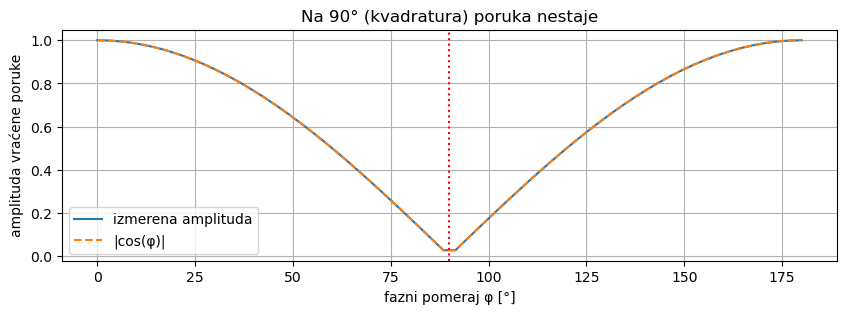

In [9]:
m_ton = np.cos(2 * np.pi * f1 * t)
mod_ton = m_ton * np.cos(2 * np.pi * fc * t)

def amp_na(x, f):
    H = np.fft.fft(x) / len(x) * 2
    w = np.fft.fftfreq(len(x), d=1/fs)
    return np.abs(H[np.argmin(np.abs(w - f))])

faze = np.linspace(0, np.pi, 60)
vraceno = [amp_na(mod_ton * np.cos(2 * np.pi * fc * t + ph) * 2, f1) for ph in faze]

plt.figure(figsize=(10, 3))
plt.plot(np.degrees(faze), vraceno, label="izmerena amplituda")
plt.plot(np.degrees(faze), np.abs(np.cos(faze)), "--", label="|cos(φ)|")
plt.axvline(90, color="r", ls=":"); plt.xlabel("fazni pomeraj φ [°]")
plt.ylabel("amplituda vraćene poruke"); plt.legend(); plt.grid()
plt.title("Na 90° (kvadratura) poruka nestaje")
plt.show()

## 5. Klasični AM i anvelopa

Da bi se izbegao problem faze, poruci se doda konstanta (DC) tako da izraz bude uvek pozitivan.
Tada vrhovi modulisanog signala prate poruku — to je **anvelopa**:

$$ s(t) = \big(1 + k_a\, m(t)\big)\cos(2\pi f_c t) $$

- 1 je dodata jednosmerna komponenta (DC), drži izraz pozitivnim,
- $k_a$ je **indeks modulacije** (koliko duboko poruka talasa amplitudu),
- zagrada $1+k_a m(t)$ je anvelopa, a $\cdot\cos$ je prebacuje na $f_c$.

Demodulacija ne traži usaglašen oscilator — dovoljan je **detektor anvelope** (dioda).
Za $k_a<1$ anvelopa lepo prati poruku; za $k_a>1$ nastaje **premodulacija** (anvelopa se izobliči).

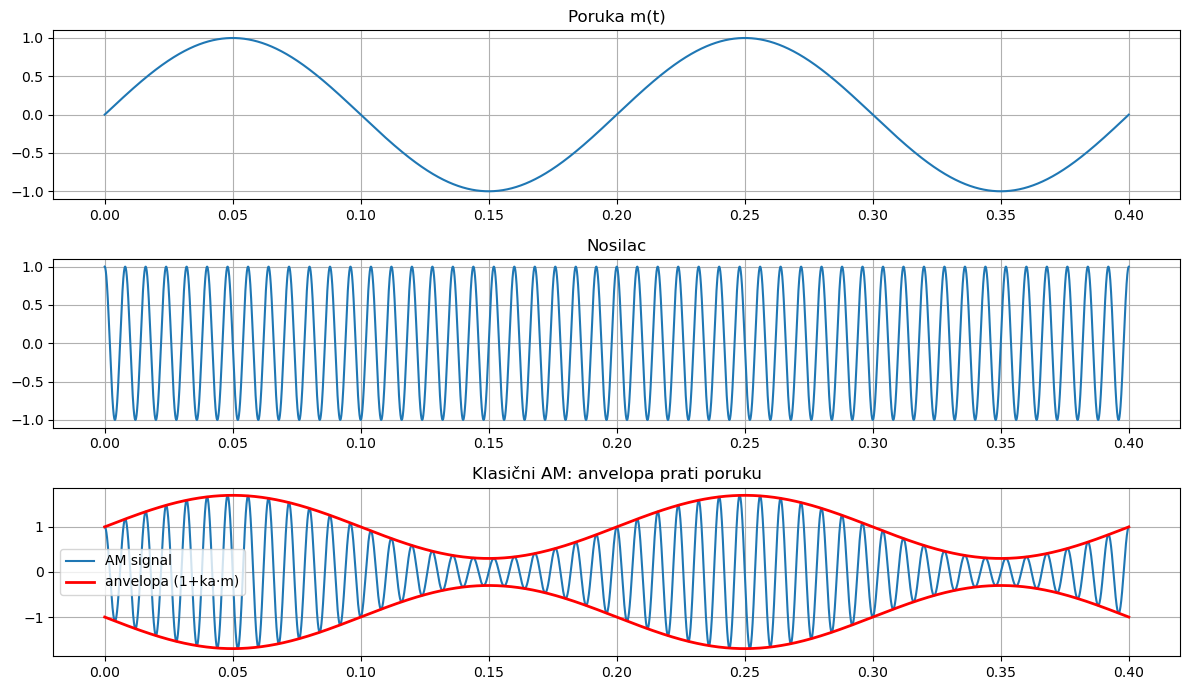

In [10]:
ka = 0.7
poruka = np.sin(2 * np.pi * 5 * t)
nosac = np.cos(2 * np.pi * fc * t)
am = (1 + ka * poruka) * nosac
anvelopa = 1 + ka * poruka

win = t < 0.4   # kratak prozor radi preglednosti
plt.figure(figsize=(12, 7))
plt.subplot(3, 1, 1); plt.plot(t[win], poruka[win]); plt.grid(); plt.title("Poruka m(t)")
plt.subplot(3, 1, 2); plt.plot(t[win], nosac[win]); plt.grid(); plt.title("Nosilac")
plt.subplot(3, 1, 3)
plt.plot(t[win], am[win], label="AM signal")
plt.plot(t[win], anvelopa[win], "r", linewidth=2, label="anvelopa (1+ka·m)")
plt.plot(t[win], -anvelopa[win], "r", linewidth=2)
plt.legend(); plt.grid(); plt.title("Klasični AM: anvelopa prati poruku")
plt.tight_layout(); plt.show()

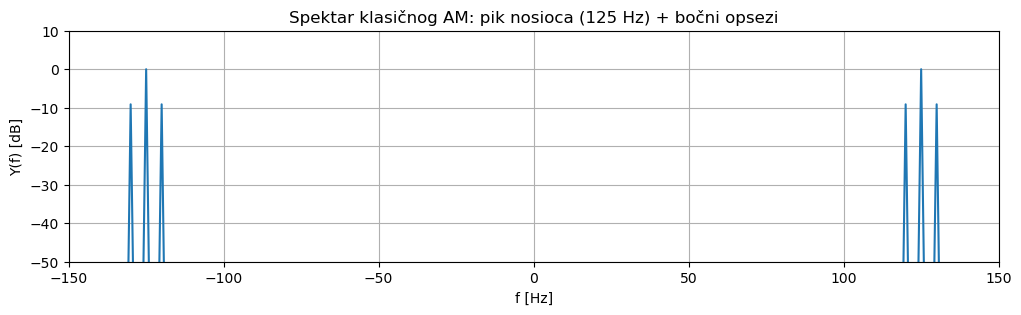

In [11]:
plt.figure(figsize=(12, 3))
showSpect(am); plt.grid()
plt.title("Spektar klasičnog AM: pik nosioca (125 Hz) + bočni opsezi")
plt.show()

Raspisivanjem $(1+k_a m)\cos = \cos + k_a m\cos$ vidi se da klasični AM = **pik nosioca + dva bočna
opsega**. Cena komfora je taj nosilac koji ne nosi informaciju, a troši snagu (zato je DSB-SC štedljiviji).
AM je i osetljiv na šum jer se detektuje amplituda.

**Interaktivno** — AM: prebaci režim i pomeri nosilac, učestanost poruke i indeks $k_a$:

In [12]:
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown

def prikazi_am(fc_=125, fm_=10, ka_=0.6, rezim="Klasični AM"):
    t_a = np.linspace(0, 1, fs, endpoint=False)
    m = np.sin(2*np.pi*fm_*t_a)
    if rezim == "DSB-SC":
        env = np.abs(m); s = m*np.cos(2*np.pi*fc_*t_a)
    else:
        env = 1 + ka_*m; s = env*np.cos(2*np.pi*fc_*t_a)
    win = t_a < 0.25
    plt.figure(figsize=(12, 5))
    plt.subplot(2, 1, 1)
    plt.plot(t_a[win], s[win], label="signal")
    plt.plot(t_a[win], env[win], "r", lw=2, label="anvelopa")
    plt.plot(t_a[win], -env[win], "r", lw=2)
    plt.title(f"{rezim} — vreme"); plt.legend(); plt.grid()
    plt.subplot(2, 1, 2)
    showSpect(s, lim=(-280, 280)); plt.grid(); plt.title("spektar")
    plt.tight_layout(); plt.show()

interact(prikazi_am,
         fc_=IntSlider(min=60, max=220, step=5, value=125),
         fm_=IntSlider(min=2, max=20, step=1, value=10),
         ka_=FloatSlider(min=0, max=1.8, step=0.05, value=0.6),
         rezim=Dropdown(options=["DSB-SC", "Klasični AM"], value="Klasični AM"));

interactive(children=(IntSlider(value=125, description='fc_', max=220, min=60, step=5), IntSlider(value=10, de…

### 5.1 Detektor anvelope (diodni)

Pošto kod klasičnog AM-a anvelopa verno prati poruku, dovoljno je **pratiti vrhove** signala. To radi diodni detektor: **dioda** propušta samo pozitivne vrhove i puni **kondenzator** do njih, a **otpornik** ga polako prazni između vrhova. Napon na kondenzatoru tako odgovara anvelopi.

Ključ je vreme $RC$: mora biti mnogo duže od periode nosioca (da ne prati brzo treperenje), ali mnogo kraće od periode poruke (da stigne za njom):

$$ \frac{1}{f_c} \ll RC \ll \frac{1}{f_m} $$

Prekratko $RC$ → talasanje nosioca; predugo $RC$ → seče padove (kašnjenje). Pomeri klizač i vidi:

In [13]:
from ipywidgets import interact, FloatSlider

fs_e = 40000
t_e = np.linspace(0, 1, fs_e, endpoint=False)
fc_e, fm_e, ka_e = 1500, 20, 0.8
poruka_e = np.sin(2*np.pi*fm_e*t_e)
am_e = (1 + ka_e*poruka_e)*np.cos(2*np.pi*fc_e*t_e)

def detektor_anvelope(x, fs_, RC):
    out = np.empty_like(x); Vc = x[0]; k = np.exp(-1/(fs_*RC))
    for i in range(len(x)):
        Vc *= k
        if x[i] > Vc: Vc = x[i]
        out[i] = Vc
    return out

def prikazi_detektor(RC=0.005):
    anv = detektor_anvelope(am_e, fs_e, RC)
    win = t_e < 0.1
    plt.figure(figsize=(12, 4))
    plt.plot(t_e[win], am_e[win], alpha=0.35, label="AM signal")
    plt.plot(t_e[win], anv[win], "r", lw=2, label="izlaz detektora")
    plt.plot(t_e[win], 1 + ka_e*poruka_e[win], "k--", lw=1.5, label="prava anvelopa")
    plt.title(f"Diodni detektor anvelope (RC = {RC:.4f} s)")
    plt.legend(); plt.grid(); plt.show()

interact(prikazi_detektor, RC=FloatSlider(min=0.0003, max=0.04, step=0.0003, value=0.005, readout_format=".4f"));

interactive(children=(FloatSlider(value=0.005, description='RC', max=0.04, min=0.0003, readout_format='.4f', s…

## 6. FM — frekvencijska modulacija

Umesto amplitude, poruka talasa **trenutnu učestanost** nosioca: $f_i(t) = f_c + k_f\, m(t)$.
Pošto je faza integral učestanosti, u argument kosinusa ide **integral** poruke (u kodu: `cumsum`):

$$ s(t) = \cos\!\Big(2\pi f_c t + 2\pi k_f \!\int_0^t m(\tau)\,d\tau\Big) $$

Spektar FM-a je teorijski beskonačan, ali je najveći deo snage oko nosioca. FM je **otporniji na šum**
od AM-a jer informacija nije u amplitudi.

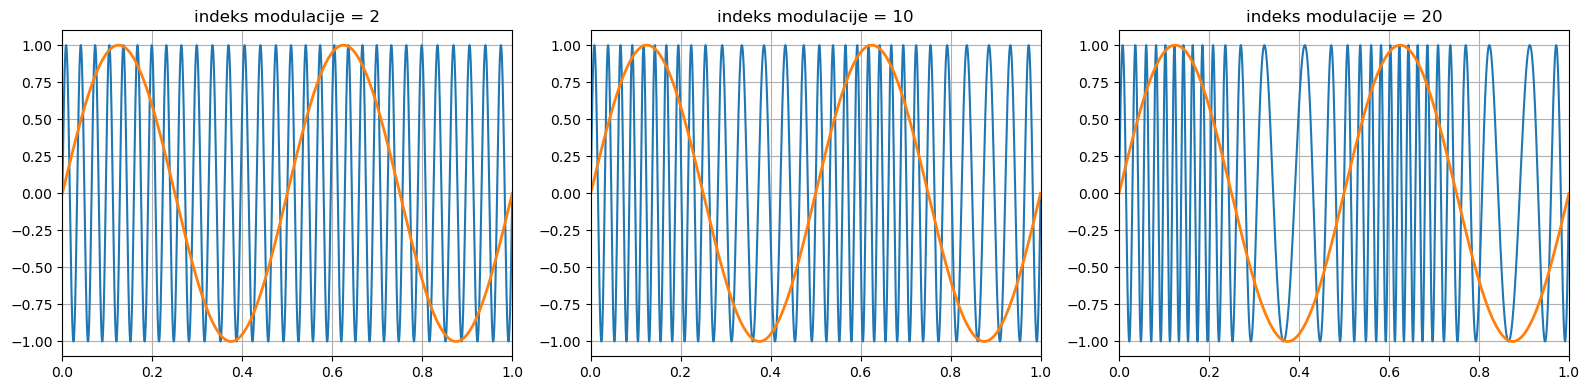

In [14]:
fcAlt = 30
t_fm = np.linspace(0, 1, fs)
poruka_fm = np.sin(2 * np.pi * 2 * t_fm)

plt.figure(figsize=(16, 4))
for i, modIndex in enumerate([2, 10, 20]):
    fmPhase = 2 * np.pi * np.cumsum((fcAlt + modIndex * poruka_fm) / fs)
    plt.subplot(1, 3, i + 1)
    plt.plot(t_fm, np.sin(fmPhase))
    plt.plot(t_fm, poruka_fm, linewidth=2)
    plt.title(f"indeks modulacije = {modIndex}")
    plt.xlim([0, 1]); plt.grid()
plt.tight_layout(); plt.show()

Tamo gde je poruka u vrhu, talasi su gusti (viša učestanost); u dolu su retki. Veći indeks
modulacije = dublja modulacija. Demodulacija se radi traženjem prolazaka kroz nulu ili
prebacivanjem nazad u AM.

**Interaktivno** — pomeri devijaciju (dubinu modulacije) i gledaj gustinu talasa:

In [15]:
from ipywidgets import interact, FloatSlider

def prikazi_fm(devijacija=10.0):
    fs_f = 5000
    t_f = np.linspace(0, 1, fs_f, endpoint=False)
    fc_f = 30
    m = np.sin(2*np.pi*2*t_f)
    faza = 2*np.pi*np.cumsum(fc_f + devijacija*m)/fs_f
    plt.figure(figsize=(12, 3))
    plt.plot(t_f, np.sin(faza), label="FM signal")
    plt.plot(t_f, m, linewidth=2, label="poruka")
    plt.title(f"FM — devijacija = {devijacija}"); plt.legend(); plt.grid(); plt.show()

interact(prikazi_fm, devijacija=FloatSlider(min=0, max=40, step=1, value=10));

interactive(children=(FloatSlider(value=10.0, description='devijacija', max=40.0, step=1.0), Output()), _dom_c…

## 7. Prelaz na digitalno

Moderni sistemi šalju **bite** — otporniji su na šum (prijemnik bira između diskretnih vrednosti).
Svaki bit „razvučemo" da traje neki interval (simbol). Otpornost se meri **BER** krivama
(bit error rate vs SNR). Pri pravougaonim impulsima javlja se **intersimbolska interferencija (ISI)**,
koju rešava posebno oblikovan impuls (raised-cosine) — to je po prirodi filtar, pa tu temu ovde
samo pominjemo, bez projektovanja.

## 8. FSK — bit bira učestanost

Svakom bitu se dodeli jedna učestanost (rođak FM-a). Binarni FSK koristi $f_0$ za 0 i $f_1$ za 1;
sa više učestanosti jedan simbol nosi više bita (4-FSK nosi po 2 bita). FSK je nosio podatke kroz
telefonske linije u doba dial-up modema.

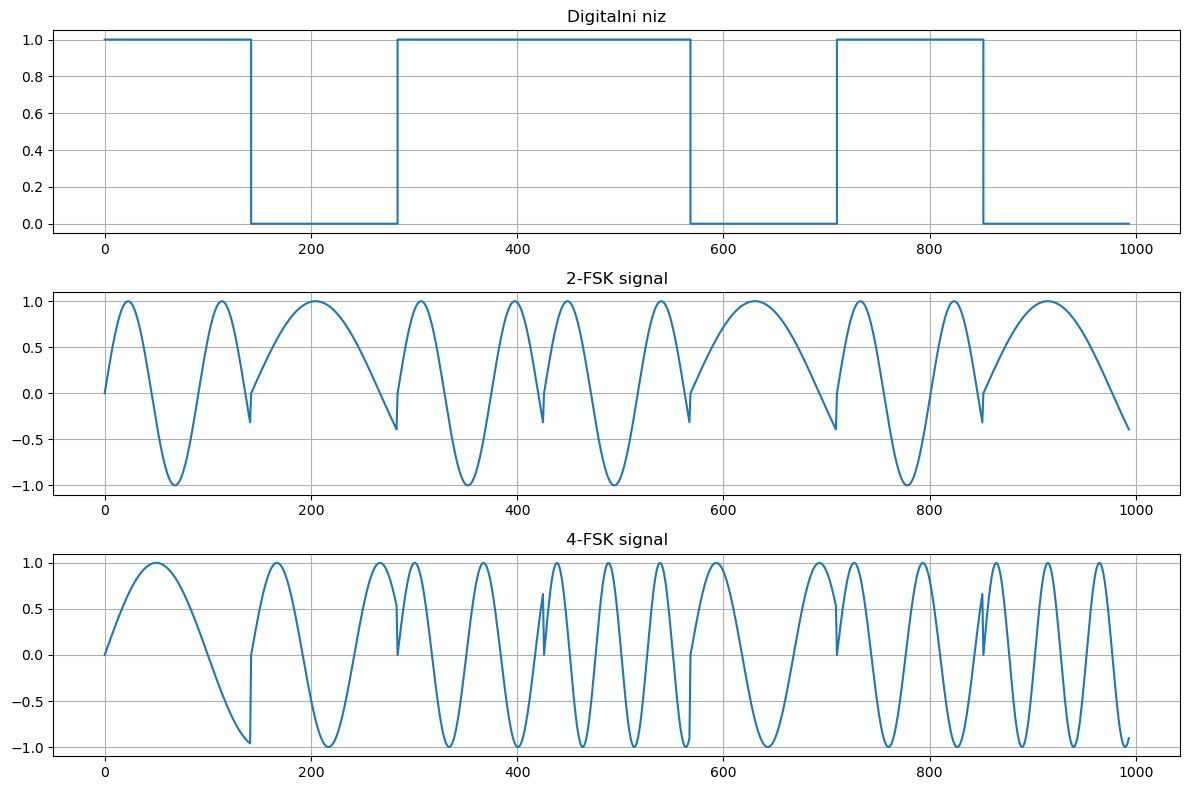

In [16]:
fsk_fs = 1000
T = 1
bits = [1, 0, 1, 1, 0, 1, 0]
bits4 = [(0,0),(0,1),(1,0),(1,1),(0,1),(1,0),(1,1)]
tb = np.arange(0, T, 1/fsk_fs)
seg = len(tb) // len(bits)

def gen_fsk(f0, f1):
    out = np.array([])
    for b in bits:
        fr = f0 if b == 0 else f1
        out = np.concatenate((out, np.sin(2 * np.pi * fr * tb[:seg])))
    return out

def gen_4fsk(fmap):
    out = np.array([])
    for b in bits4:
        out = np.concatenate((out, np.sin(2 * np.pi * fmap[b] * tb[:seg])))
    return out

digital = np.repeat(bits, seg)
fsk = gen_fsk(4, 11)
fsk4 = gen_4fsk({(0,0):5, (0,1):10, (1,0):15, (1,1):20})

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1); plt.step(np.arange(len(digital)), digital, where="post")
plt.title("Digitalni niz"); plt.grid()
plt.subplot(3, 1, 2); plt.plot(fsk); plt.title("2-FSK signal"); plt.grid()
plt.subplot(3, 1, 3); plt.plot(fsk4); plt.title("4-FSK signal"); plt.grid()
plt.tight_layout(); plt.show()